<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/main/Hw3_problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, accuracy_score

In [31]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float64) / 255.0
y_digits = mnist.target.astype(int).reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y_digits.shape)

X shape: (70000, 784)
y shape: (70000, 1)


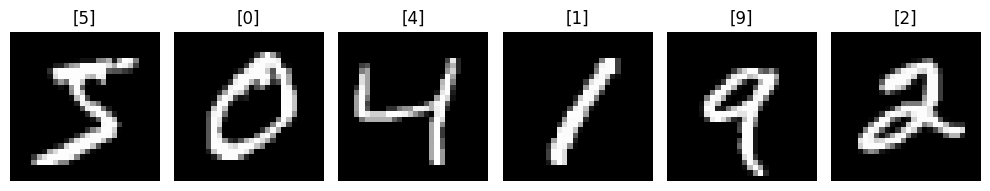

In [32]:
n_preview = 6
plt.figure(figsize=(10, 2))
for i in range(n_preview):
    plt.subplot(1, n_preview, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.title(str(y_digits[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [33]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1.0

X_normalized = (X - X_mean) / X_std

X_with_bias = np.c_[np.ones((X_normalized.shape[0], 1)), X_normalized]
print("Feature matrix shape (with bias):", X_with_bias.shape)

Feature matrix shape (with bias): (70000, 785)


In [34]:
def sigmoid(z):
    """
    Sigmoid function to map values to [0, 1]
    """
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def nll_cost(X, y, theta):
    """
    Compute negative log-likelihood cost for logistic regression.
    cost = -(1/m) * sum(y*log(pred) + (1-y)*log(1-pred))
    """
    m = len(y)
    z = X @ theta
    predictions = sigmoid(z)

    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)

    cost = -(1 / m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

def nll_gradient(X, y, theta):
    """
    Compute gradient of negative log-likelihood cost.
    """
    m = len(y)
    z = X @ theta
    predictions = sigmoid(z)
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return gradient

In [35]:
def logistic_regression_gd(X, y, learning_rate=0.1, n_iterations=1000):
    """
    Batch gradient descent for binary logistic regression.
    """
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(n_iterations):
        grad = nll_gradient(X, y, theta)
        theta = theta - learning_rate * grad
        cost_history.append(nll_cost(X, y, theta))

    return theta, cost_history


In [36]:
print("\n Binary Logistic Regression (Even vs Odd) ")

y_even = (y_digits % 2 == 0).astype(int).reshape(-1, 1)

print("Even label distribution:")
print(pd.Series(y_even.flatten()).value_counts())

theta_even, cost_hist_even = logistic_regression_gd(X_with_bias, y_even,learning_rate=0.1,n_iterations=1000)

print(f"\nFinal Cost: {cost_hist_even[-1]:.6f}")
print(f"  Bias: {theta_even[0, 0]:.4f}")


 Binary Logistic Regression (Even vs Odd) 
Even label distribution:
0    35582
1    34418
Name: count, dtype: int64

Final Cost: 0.249364
  Bias: 0.0477


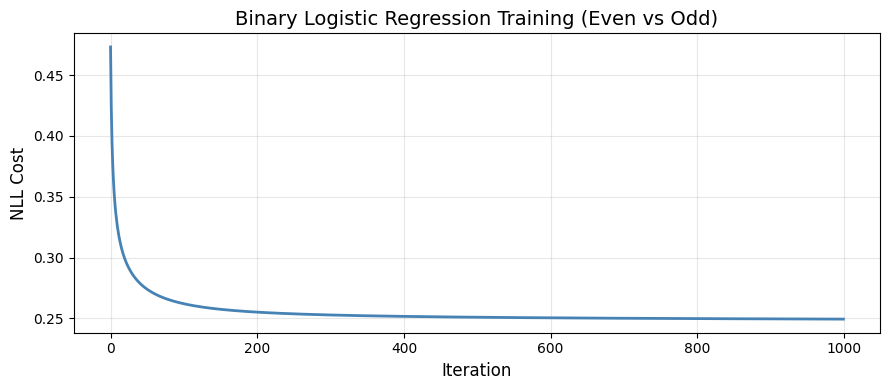

In [37]:
plt.figure(figsize=(9, 4))
plt.plot(cost_hist_even, linewidth=2, color='steelblue')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("NLL Cost", fontsize=12)
plt.title("Binary Logistic Regression Training (Even vs Odd)",fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Even vs Odd accuracy: 0.9033714285714286

Confusion Matrix (Even vs Odd):
 [[32236  3346]
 [ 3418 31000]]


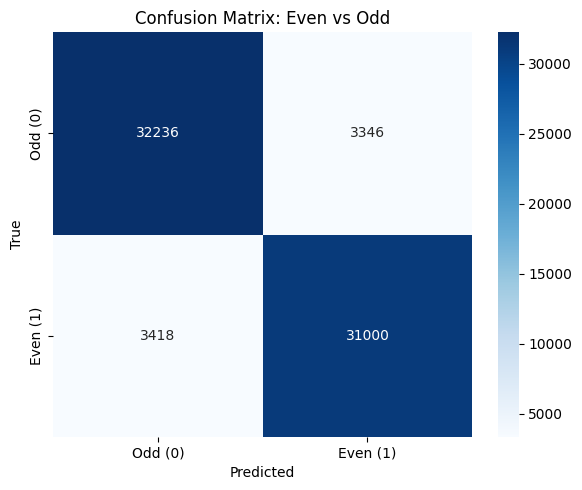

In [38]:
p_even = sigmoid(X_with_bias @ theta_even)
y_pred_even = (p_even >= 0.5).astype(int)

acc_even = accuracy_score(y_even, y_pred_even)
print("Even vs Odd accuracy:", acc_even)

cm_even = confusion_matrix(y_even, y_pred_even)
print("\nConfusion Matrix (Even vs Odd):\n", cm_even)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_even, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Odd (0)", "Even (1)"],
            yticklabels=["Odd (0)", "Even (1)"])
plt.title("Confusion Matrix: Even vs Odd")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [39]:
def softmax(z):
    """
    Softmax function to convert logits to probabilities.
    """
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot_encode(y, num_classes):
    """
    Convert class labels to one-hot encoded vectors.
    """
    m = len(y)
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y.flatten()] = 1
    return one_hot

def softmax_nll_cost(X, y_one_hot, theta):
    """
    Compute softmax negative log-likelihood cost.
    Cost = -(1/m) * sum(y * log(softmax(X*theta)))
    """
    m = X.shape[0]
    z = X @ theta
    predictions = softmax(z)

    predictions = np.clip(predictions, 1e-15, 1)

    cost = -(1 / m) * np.sum(y_one_hot * np.log(predictions))
    return cost

def softmax_nll_gradient(X, y_one_hot, theta):
    """
    Compute gradient of softmax negative log-likelihood cost.
    """
    m = X.shape[0]
    z = X @ theta
    predictions = softmax(z)
    errors = predictions - y_one_hot
    gradient = (1 / m) * (X.T @ errors)
    return gradient

In [40]:
def softmax_regression(X, y, num_classes, learning_rate=0.1, n_iterations=1000):
    """
    Perform softmax regression using gradient descent.
    """
    m, n = X.shape
    theta = np.zeros((n, num_classes))
    cost_history = []
    y = y.reshape(-1, 1)


    y_one_hot = one_hot_encode(y, num_classes)

    for i in range(n_iterations):
        gradient = softmax_nll_gradient(X, y_one_hot, theta)

        theta = theta - learning_rate * gradient

        cost = softmax_nll_cost(X, y_one_hot, theta)
        cost_history.append(cost)

    return theta, cost_history, y_one_hot

In [24]:
print("\n--- Task B: Softmax Regression (Digit 0-9) ---")

num_classes = 10
theta_digits, cost_hist_digits, y_one_hot = softmax_regression(X_with_bias, y_digits,num_classes=num_classes,learning_rate=0.1,n_iterations=1000)

print(f"\nFinal Cost: {cost_hist_digits[-1]:.6f}")
print(f"\nTheta shape (n_features x n_classes): {theta_digits.shape}")


--- Task B: Softmax Regression (Digit 0-9) ---

Final Cost: 0.262034

Theta shape (n_features x n_classes): (785, 10)


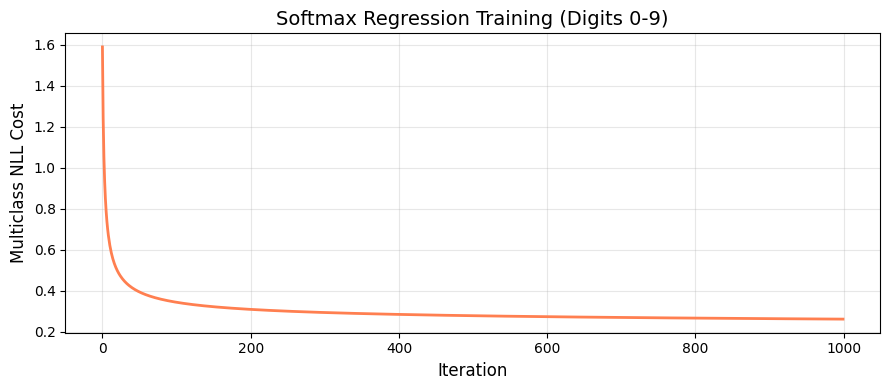

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(cost_hist_digits, linewidth=2, color='coral')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Multiclass NLL Cost", fontsize=12)
plt.title("Softmax Regression Training (Digits 0-9)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
logits = X_with_bias @ theta_digits
P = softmax(logits)
y_pred_digits = np.argmax(P, axis=1).reshape(-1,1)

acc_digits = accuracy_score(y_digits, y_pred_digits)
print("Digit classification accuracy:", acc_digits)

cm_digits = confusion_matrix(y_digits, y_pred_digits)
print("\nConfusion Matrix (Digits 0-9):")
print(cm_digits)

Digit classification accuracy: 0.9272714285714285

Confusion Matrix (Digits 0-9):
[[6725    3   15   12   15   37   48   10   34    4]
 [   1 7676   35   17    7   29    8   19   75   10]
 [  50   65 6335   97   91   24   74   88  142   24]
 [  28   47  144 6424   13  214   21   74  115   61]
 [  12   40   28    6 6428    6   58   18   34  194]
 [  67   50   29  174   72 5597  109   28  137   50]
 [  38   29   36    1   50   79 6609    5   27    2]
 [  19   52   78   22   61    8    3 6834   10  206]
 [  49  206   58  161   45  160   47   30 5974   95]
 [  41   34   15   87  193   39    4  197   41 6307]]


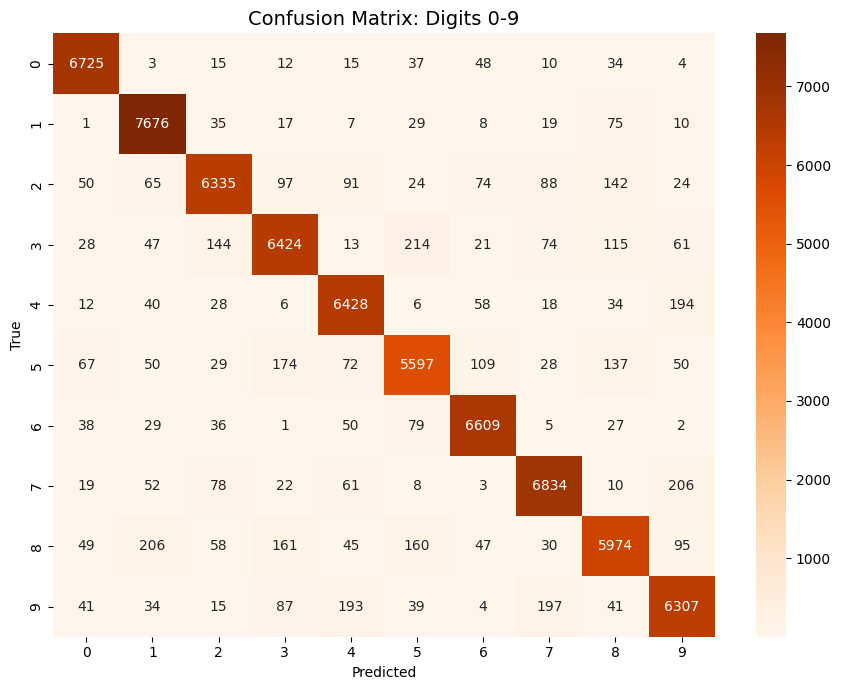

In [29]:
# Plot confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm_digits, fmt="d", cmap="Oranges", annot=True)
plt.title("Confusion Matrix: Digits 0-9", fontsize=14)
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()